In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

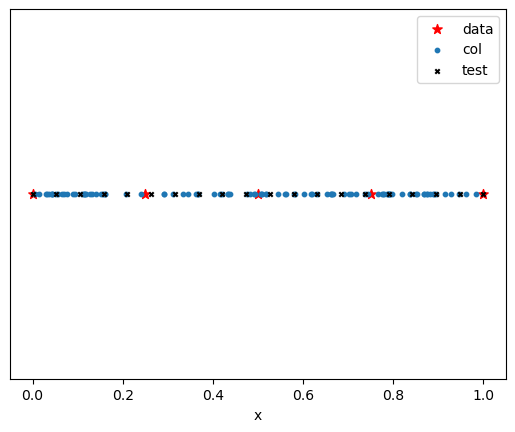

In [2]:
x_data = torch.linspace(0,1,5).view(-1,1)
x_col  = torch.rand(100,1)
x_test = torch.linspace(0,1,20).view(-1,1)

z = lambda x: np.zeros_like(x.numpy())

plt.scatter(x_data.numpy(), z(x_data), marker='*', s=50, label='data', color= 'red')
plt.scatter(x_col.numpy(),  z(x_col),  s=10, label='col')
plt.scatter(x_test.numpy(), z(x_test), marker='x', s=10, label='test', color= 'k')

plt.yticks([]); plt.xlabel("x"); plt.legend(); plt.show()

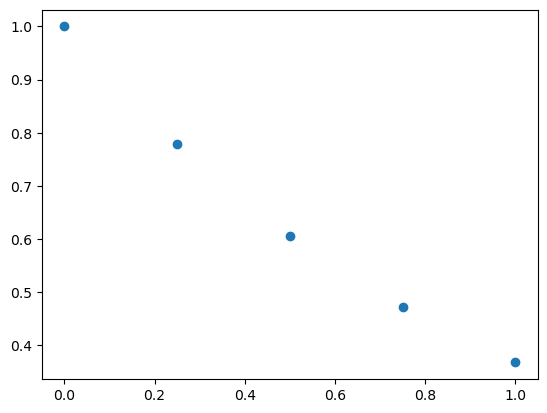

In [3]:
u_data = torch.exp(-x_data)
plt.scatter(x_data.numpy(), u_data.numpy(), label="Training data")

In [4]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

lambda_phys = 1.0
epochs = 5000

data_losses = []
physics_losses = []
total_losses = []

for epoch in range(epochs):
    optimizer.zero_grad()

    u_pred_data = model(x_data)
    data_loss = torch.mean((u_pred_data - u_data) ** 2)

    x_col_epoch = x_col.clone().detach().requires_grad_(True)
    u_col = model(x_col_epoch)

    du_dx = torch.autograd.grad( outputs=u_col,
        inputs=x_col_epoch,
        grad_outputs=torch.ones_like(u_col),
        create_graph=True)[0]

    physics_loss = torch.mean((du_dx + u_col) ** 2)

    loss = data_loss + lambda_phys * physics_loss

    loss.backward()
    optimizer.step()

    data_losses.append(data_loss.item())
    physics_losses.append(physics_loss.item())
    total_losses.append(loss.item())



In [5]:
u_pred = model(x_test).detach().numpy()
u_true = torch.exp(-x_test).detach().numpy()

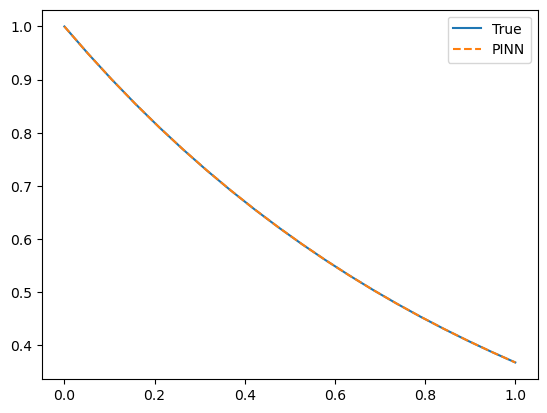

In [6]:
plt.plot(x_test.numpy(), u_true, label="True")
plt.plot(x_test.numpy(), u_pred, "--", label="PINN")
plt.legend(); plt.show()